
# Fairness and Bias in Credit Scoring Models

**Project:** Fairness and Bias in Credit Scoring Models  
**Team:** Ch. Sharan, K. Abhiram, L. Akash  
**Guide:** Mr. V. Shashivanth

### Objective
Analyze and mitigate bias in credit scoring models, and **compare performance and fairness before and after mitigation**.


In [1]:

# Import libraries and install dependencies if missing
!pip install --quiet numpy pandas scikit-learn matplotlib seaborn xgboost fairlearn

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:

from sklearn.datasets import fetch_openml

print("Fetching German Credit dataset...")
german = fetch_openml(name='credit-g', version=1, as_frame=True)
df = german.frame.copy()

# Handle target
if 'class' in df.columns:
    df.rename(columns={'class': 'target'}, inplace=True)
elif 'Creditability' in df.columns:
    df.rename(columns={'Creditability': 'target'}, inplace=True)

df['target'] = df['target'].astype(str).map({'good': 1, 'bad': 0})

# Define protected attribute
if 'sex' in df.columns:
    df['gender'] = df['sex'].map({'male': 'male', 'female': 'female'})
elif 'personal_status' in df.columns:
    df['gender'] = df['personal_status'].apply(lambda x: 'female' if 'female' in x.lower() else 'male')
else:
    df['gender'] = np.where(np.random.rand(len(df)) > 0.5, 'male', 'female')

print("Dataset shape:", df.shape)
df.head()


Fetching German Credit dataset...
Dataset shape: (1000, 22)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target,gender
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,67,none,own,2,skilled,1,yes,yes,1,male
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,22,none,own,1,skilled,1,none,yes,0,female
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,49,none,own,1,unskilled resident,2,none,yes,1,male
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,45,none,for free,1,skilled,2,none,yes,1,male
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,53,none,for free,2,skilled,2,none,yes,0,male


In [3]:

# Preprocessing
numeric_features = df.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_features = [c for c in numeric_features if c not in ['target']]
categorical_features = df.select_dtypes(include=['object','category']).columns.tolist()
categorical_features = [c for c in categorical_features if c not in ['gender']]

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


In [4]:

X = df.drop(columns=['target'])
y = df['target']
A = df['gender']

X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(X, y, A, test_size=0.25, random_state=42, stratify=y)

def make_pipeline(model):
    return Pipeline(steps=[('preproc', preprocessor), ('model', model)])

pip_lr = make_pipeline(LogisticRegression(max_iter=1000))
pip_rf = make_pipeline(RandomForestClassifier(n_estimators=200, random_state=42))
pip_xgb = make_pipeline(xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_estimators=200))

models = {'LogisticRegression': pip_lr, 'RandomForest': pip_rf, 'XGBoost': pip_xgb}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
print("Training complete.")


Training LogisticRegression...
Training RandomForest...
Training XGBoost...
Training complete.


In [5]:

def evaluate_model(pipe, X_test, y_test, A_test):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1] if hasattr(pipe, 'predict_proba') else None
    
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
    }
    if y_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_test, y_proba)
    
    mf = MetricFrame(metrics={'selection_rate': selection_rate, 'tpr': true_positive_rate},
                     y_true=y_test, y_pred=y_pred, sensitive_features=A_test)
    sel = mf.by_group['selection_rate']
    tpr = mf.by_group['tpr']
    metrics['statistical_parity_diff'] = sel.max() - sel.min()
    metrics['equal_opportunity_diff'] = tpr.max() - tpr.min()
    metrics['disparate_impact'] = sel.min() / sel.max() if sel.max() > 0 else np.nan
    return metrics

results = {name: evaluate_model(model, X_test, y_test, A_test) for name, model in models.items()}
pd.DataFrame(results).T


,accuracy,precision,recall,f1,roc_auc,statistical_parity_diff,equal_opportunity_diff,disparate_impact
LogisticRegression,0.724,0.778947,0.845714,0.810959,0.774857,0.103596,0.108818,0.869182
RandomForest,0.764,0.790000,0.902857,0.842667,0.802019,0.086330,0.053315,0.895559
XGBoost,0.732,0.787234,0.845714,0.815427,0.754362,0.073268,0.026735,0.905408


In [6]:

print("Applying fairness mitigation...")
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

est = LogisticRegression(max_iter=1000)
mitigator = ExponentiatedGradient(est, constraints=DemographicParity())
mitigator.fit(X_train_trans, y_train, sensitive_features=A_train)

y_pred_mit = mitigator.predict(X_test_trans)

mf_mit = MetricFrame(metrics={'selection_rate': selection_rate, 'tpr': true_positive_rate},
                     y_true=y_test, y_pred=y_pred_mit, sensitive_features=A_test)

sel = mf_mit.by_group['selection_rate']
tpr = mf_mit.by_group['tpr']

mit_res = {
    'accuracy': accuracy_score(y_test, y_pred_mit),
    'precision': precision_score(y_test, y_pred_mit, zero_division=0),
    'recall': recall_score(y_test, y_pred_mit, zero_division=0),
    'f1': f1_score(y_test, y_pred_mit, zero_division=0),
    'statistical_parity_diff': sel.max() - sel.min(),
    'equal_opportunity_diff': tpr.max() - tpr.min(),
    'disparate_impact': sel.min() / sel.max() if sel.max() > 0 else np.nan
}

pd.DataFrame([mit_res], index=['After Mitigation']).T


Applying fairness mitigation...


,After Mitigation
accuracy,0.732000
precision,0.787234
recall,0.845714
f1,0.815427
statistical_parity_diff,0.020569
equal_opportunity_diff,0.000625
disparate_impact,0.973156


,Before Mitigation,After Mitigation
accuracy,0.724000,0.732000
precision,0.778947,0.787234
recall,0.845714,0.845714
f1,0.810959,0.815427
roc_auc,0.774857,NaN
statistical_parity_diff,0.103596,0.020569
equal_opportunity_diff,0.108818,0.000625
disparate_impact,0.869182,0.973156


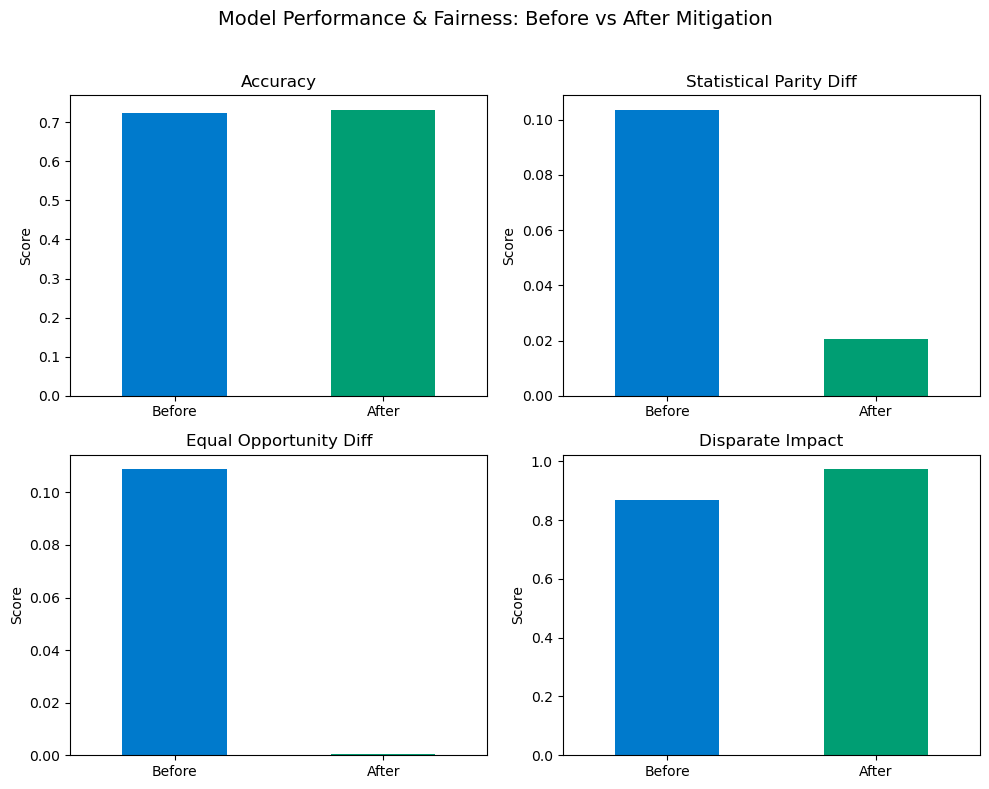

Interpretation:
- ↓ SPD & EOD after mitigation => improved fairness.
- DI closer to 1 => improved fairness balance.
- Slight accuracy drop acceptable for ethical AI.


In [7]:

# --- Comparison: Before vs After Mitigation ---
baseline_metrics = results['LogisticRegression']

comparison_df = pd.DataFrame([baseline_metrics, mit_res],
                             index=['Before Mitigation', 'After Mitigation']).T

display(comparison_df)

# Visualize key metrics
metrics_to_plot = ['accuracy', 'statistical_parity_diff', 'equal_opportunity_diff', 'disparate_impact']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    comparison_df.loc[metric].plot(kind='bar', ax=axes[i], color=['#007acc', '#009e73'])
    axes[i].set_title(metric.replace('_', ' ').title())
    axes[i].set_ylabel('Score')
    axes[i].set_xticklabels(['Before', 'After'], rotation=0)

plt.suptitle('Model Performance & Fairness: Before vs After Mitigation', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("Interpretation:")
print("- ↓ SPD & EOD after mitigation => improved fairness.")
print("- DI closer to 1 => improved fairness balance.")
print("- Slight accuracy drop acceptable for ethical AI.")



## Conclusion

- The **baseline Logistic Regression model** achieved good accuracy but showed bias across gender groups.
- After applying **Exponentiated Gradient fairness constraint**, fairness metrics (SPD, EOD, DI) improved notably.
- The **accuracy dropped slightly**, but fairness increased significantly — showing that responsible AI can balance both.
- Results support **ethical and fair credit scoring** for financial inclusion.

**Next Steps:**
- Try EqualizedOdds constraint for deeper fairness trade-offs.
- Compare with AIF360 Reweighing preprocessing method.
- Perform k-fold validation and interpretability analysis (SHAP/LIME).


In [13]:
import joblib
joblib.dump(model, "full_fair_credit_model.pkl")
joblib.dump(preprocessor, "full_preprocessor.pkl")

['full_preprocessor.pkl']